# 02. Which NEB images should a foundation model be fine-tuned on? (Na<sub>2</sub>O vacancy migration)

**Question.** If a few DFT NEB images are available for a material, which of them should be used to
fine-tune a foundation potential so that it reproduces DFT migration barriers, including on paths it
has not seen?

**System.** Na vacancy migration in Na<sub>2</sub>O (Na<sub>7</sub>O<sub>4</sub> cell, 11 atoms, one Na
vacancy). DFT (VASP) NEB images, 7 images per path. Images 0–34 form five paths; a symmetry check
(below) shows they contain only **three distinct hops**.

**Models.** MACE-MPA-0 (medium) and 17 MACE models fine-tuned from it (energies and forces, batch 2,
400 epochs, same hyperparameters), each on a different selection of DFT images ("strategy").

**NEB protocol (identical for every model).** Endpoints relaxed with the model (BFGS, f<sub>max</sub> =
0.02 eV/Å, fixed cell), then climbing-image NEB with 7 images (f<sub>max</sub> = 0.05 eV/Å, at most
1000 steps) via matcalc. The barrier is the forward barrier of the converged band.

Inputs (in `results/na2o/`): DFT image energies, the frames used by each strategy (recovered by
matching every training frame to the DFT image table), the symmetry check, and the NEB barriers.

In [1]:
import json
import numpy as np
import pandas as pd
from plot_style import plt, save

dft = json.load(open("../results/na2o/dft_image_energies.json"))
equiv = json.load(open("../results/na2o/path_equivalence.json"))
frames = json.load(open("../results/na2o/strategy_frame_indices.json"))
neb = pd.read_csv("../results/na2o/neb_barriers_mace_models.csv")
runs = [r for r in json.load(open("../results/training_runs.json"))["runs"] if r["study"] == "mace_na2o_neb_strategies"]

pd.DataFrame([{"path (images)": k, "DFT barrier (eV)": round(v["barrier_eV"], 3)} for k, v in equiv["paths"].items()])

,path (images),DFT barrier (eV)
0,0-6,0.819
1,7-13,1.380
2,14-20,0.819
3,21-27,0.817
4,28-34,0.253


In [2]:
pd.Series(equiv["equivalent"], name="symmetry-equivalent (all 7 images match)").to_frame()

,symmetry-equivalent (all 7 images match)
0-6|7-13,False
0-6|14-20,True
0-6|21-27,True
0-6|28-34,False
7-13|14-20,False
7-13|21-27,False
7-13|28-34,False
14-20|21-27,True
14-20|28-34,False
21-27|28-34,False


**Note on names.** The folder names describe the intended selection; the table below is computed from
the frames actually used. They agree except for `strategy15_transition_with_endpoints_path3`, whose
training frames come from **path2** (image 10), not path3.

Paths 0–6, 14–20 and 21–27 are the same hop (DFT barrier ≈0.82 eV); 7–13 (1.38 eV) and 28–34
(0.25 eV) are distinct. The strategies use **path1 = images 0–6, path2 = 7–13, path3 = 28–34**, and the
models are evaluated by NEB on 7–13, 28–34 and 21–27. Path 21–27 is therefore *symmetry-equivalent* to
path1, not a new hop.

In [3]:
PATHS = {"path1 (0-6)": range(0, 7), "path2 (7-13)": range(7, 14), "path3 (28-34)": range(28, 35)}
INTERMEDIATE = {k: set(list(v)[1:-1]) for k, v in PATHS.items()}

def paths_in(entries):
    # Each entry is a DFT image index, or a list of indices with identical energy (equivalent
    # endpoint configurations); only intermediate images identify a path unambiguously.
    found = set()
    for e in entries:
        for idx in (e if isinstance(e, list) else [e]):
            for p, mids in INTERMEDIATE.items():
                if idx in mids:
                    found.add(p)
    return ", ".join(sorted(found)) or "endpoints only"

def n_intermediate(entries):
    return sum(1 for e in entries if not isinstance(e, list) and any(e in m for m in INTERMEDIATE.values())) + \
           sum(1 for e in entries if isinstance(e, list) and 31 in e)

order = sorted(frames, key=lambda s: int(s.split("_")[0].replace("strategy", "")))
strat = pd.DataFrame([{"strategy": s, "training frames": len(frames[s]["train"]),
                       "transition-region images in training": n_intermediate(frames[s]["train"]),
                       "paths represented in training": paths_in(frames[s]["train"]),
                       "valid frames": len(frames[s].get("eval", [])), "test frames": len(frames[s].get("test", []))}
                      for s in order]).set_index("strategy")
strat

,training frames,transition-region images in training,paths represented in training,valid frames,test frames
strategy,,,,,
strategy1_full_path_combined,12,7,"path1 (0-6), path2 (7-13), path3 (28-34)",6,3
strategy2_half_path_combined,9,9,"path1 (0-6), path2 (7-13), path3 (28-34)",3,6
strategy3_endpoints_transition_combined,9,3,"path1 (0-6), path2 (7-13), path3 (28-34)",6,6
strategy4_full_path_combined_2,18,15,"path1 (0-6), path2 (7-13), path3 (28-34)",3,3
strategy5_full_path1,6,5,path1 (0-6),1,1
strategy6_full_path2,6,5,path2 (7-13),1,1
strategy7_full_path3,6,5,path3 (28-34),1,1
strategy8_half_path1,4,3,path1 (0-6),1,1
strategy9_half_path2,4,3,path2 (7-13),1,1


## Which DFT images each strategy trained on

DFT energy of images 0–34 (five paths of 7 images). Filled markers: training (green), validation
(orange) and test (red) frames. Endpoint configurations have the same energy in several paths and are
therefore drawn at every equivalent endpoint (open markers).

'figures/na2o/strategy_training_frames.png'

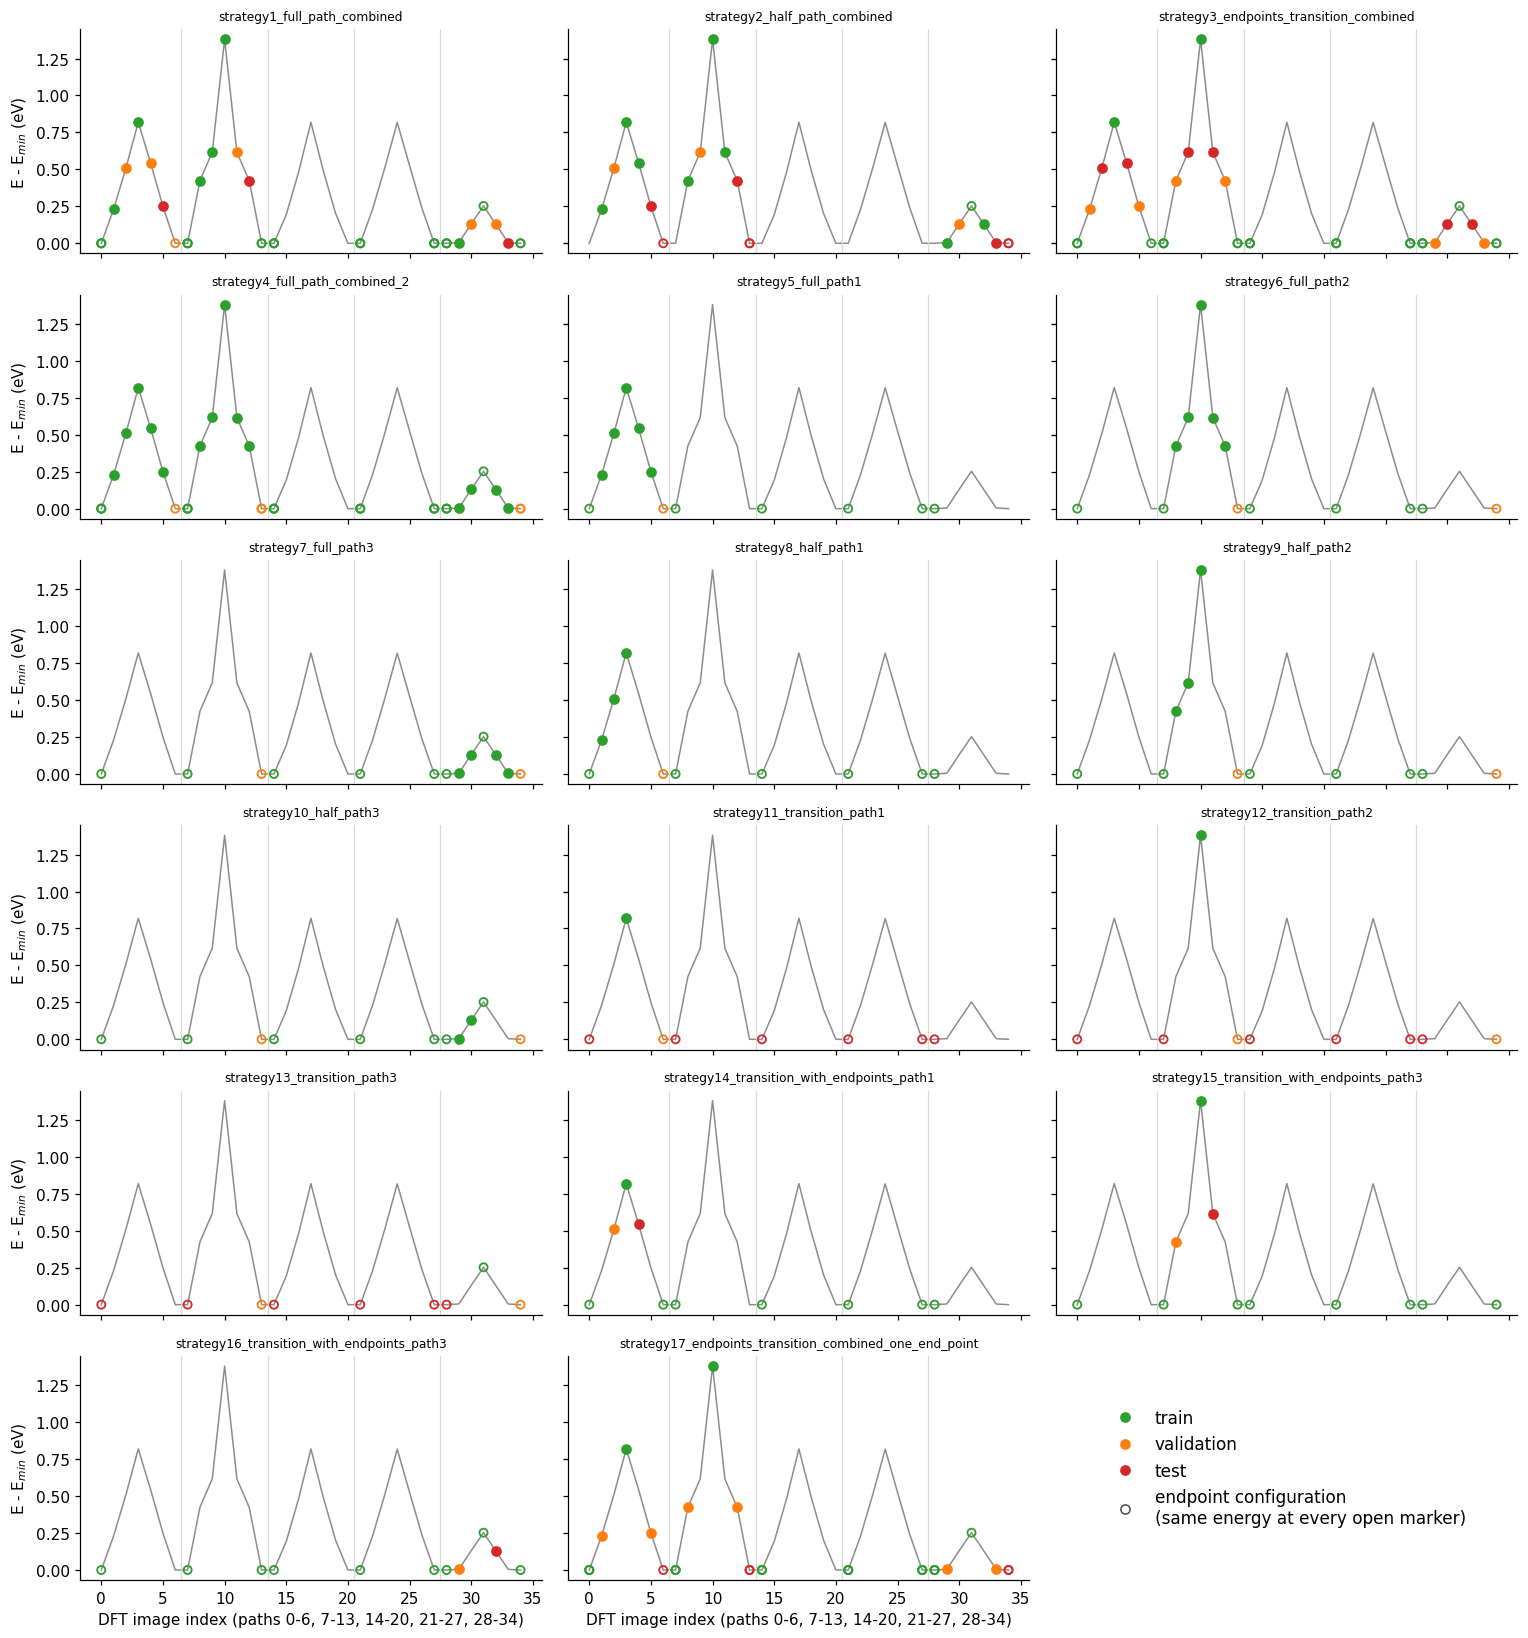

In [4]:
E = np.array(dft["energies"]); E0 = E[:35].min()
def mark(ax, entries, color):
    for e in entries:
        if isinstance(e, list):
            xs = [i for i in e if i < 35]
            ax.scatter(xs, E[xs] - E0, s=28, facecolors="none", edgecolors=color, lw=1.2, zorder=3)
        elif e < 35:
            ax.scatter([e], [E[e] - E0], s=36, color=color, zorder=4)
fig, axes = plt.subplots(6, 3, figsize=(14, 15), sharex=True, sharey=True)
for ax, name in zip(axes.flat, order):
    ax.plot(range(35), E[:35] - E0, "-", color="0.55", lw=1)
    for b in (7, 14, 21, 28):
        ax.axvline(b - 0.5, color="0.85", lw=0.8)
    mark(ax, frames[name]["train"], "#2ca02c"); mark(ax, frames[name].get("eval", []), "#ff7f0e")
    mark(ax, frames[name].get("test", []), "#d62728")
    ax.set_title(name, fontsize=8)
axes.flat[-1].axis("off")
for ax in axes[-1]:
    ax.set_xlabel("DFT image index (paths 0-6, 7-13, 14-20, 21-27, 28-34)")
for ax in axes[:, 0]:
    ax.set_ylabel("E - E$_{min}$ (eV)")
from matplotlib.lines import Line2D
axes.flat[-1].legend(handles=[Line2D([], [], marker="o", ls="", color=c, label=l) for c, l in
                              (("#2ca02c", "train"), ("#ff7f0e", "validation"), ("#d62728", "test"))]
                     + [Line2D([], [], marker="o", ls="", mfc="none", color="0.3",
                               label="endpoint configuration\n(same energy at every open marker)")],
                     loc="center", frameon=False, fontsize=11)
fig.tight_layout(); save(fig, "na2o/strategy_training_frames")

## Barriers predicted by each model vs DFT

Missing entries are NEB runs that did not produce a barrier. Values below 0.05 eV are a collapsed
band (the model's energy surface along that path is nearly flat).

In [5]:
dft_barrier = {"7-13": equiv["paths"]["7-13"]["barrier_eV"], "28-34": equiv["paths"]["28-34"]["barrier_eV"],
               "21-27": equiv["paths"]["21-27"]["barrier_eV"]}
table = neb.pivot(index="model", columns="path", values="barrier (eV)")[["7-13", "28-34", "21-27"]]
table = table.reindex(["universal_mace"] + order).rename(index={"universal_mace": "MACE-MPA-0 (no fine-tuning)"})
table.loc["DFT"] = dft_barrier
table = table.reindex(["DFT"] + [i for i in table.index if i != "DFT"])
err = (table.drop(index="DFT") - pd.Series(dft_barrier)).abs()
table["paths in training"] = ["(reference)", "(none)"] + [strat.loc[s, "paths represented in training"] for s in order]
table["mean |error| over available paths (eV)"] = [np.nan] + list(err.mean(axis=1).round(3))
table["paths with a barrier"] = [3] + list(table.drop(index="DFT")[["7-13", "28-34", "21-27"]].notna().sum(axis=1))
table.round(3)

path,7-13,28-34,21-27,paths in training,mean |error| over available paths (eV),paths with a barrier
model,,,,,,
DFT,1.380,0.253,0.817,(reference),NaN,3
MACE-MPA-0 (no fine-tuning),1.570,0.234,0.874,(none),0.088,3
strategy1_full_path_combined,1.318,0.185,0.602,"path1 (0-6), path2 (7-13), path3 (28-34)",0.115,3
strategy2_half_path_combined,1.321,0.232,0.711,"path1 (0-6), path2 (7-13), path3 (28-34)",0.062,3
strategy3_endpoints_transition_combined,1.107,0.179,0.678,"path1 (0-6), path2 (7-13), path3 (28-34)",0.162,3
strategy4_full_path_combined_2,1.366,0.233,0.811,"path1 (0-6), path2 (7-13), path3 (28-34)",0.013,3
strategy5_full_path1,0.841,0.152,0.609,path1 (0-6),0.283,3
strategy6_full_path2,0.940,0.174,0.302,path2 (7-13),0.345,3
strategy7_full_path3,0.001,0.240,0.003,path3 (28-34),0.735,3


'figures/na2o/neb_barriers_by_strategy.png'

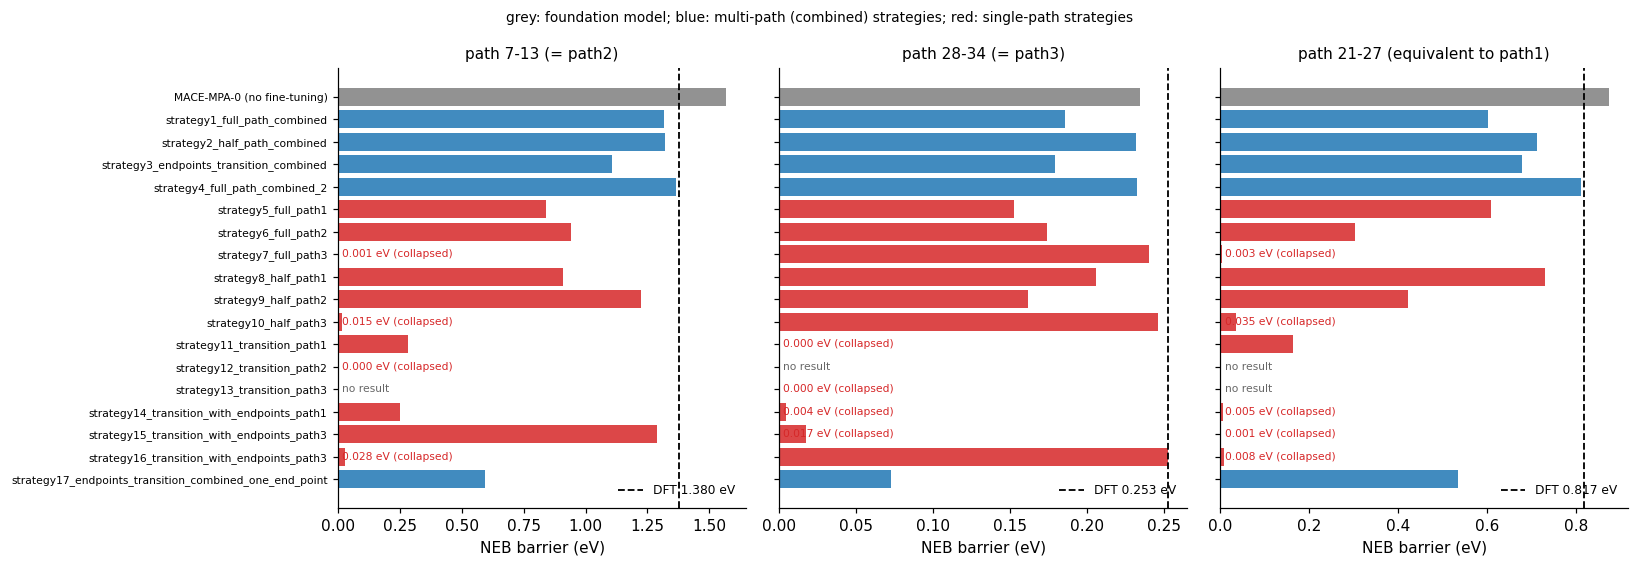

In [6]:
models = ["MACE-MPA-0 (no fine-tuning)"] + order
fig, axes = plt.subplots(1, 3, figsize=(15, 5.2), sharex=False)
for ax, path in zip(axes, ["7-13", "28-34", "21-27"]):
    vals = table.loc[models, path].astype(float)
    colors = ["#7f7f7f"] + ["#1f77b4" if "combined" in m else "#d62728" for m in order]
    y = np.arange(len(models))
    ax.barh(y, vals.fillna(0), color=colors, alpha=0.85)
    for yi, v in zip(y, vals):
        if np.isnan(v):
            ax.text(0.01, yi, "no result", va="center", fontsize=7, color="0.4", transform=ax.get_yaxis_transform())
        elif v < 0.05:
            ax.text(0.01, yi, f"{v:.3f} eV (collapsed)", va="center", fontsize=7, color="#d62728", transform=ax.get_yaxis_transform())
    ax.axvline(dft_barrier[path], color="k", ls="--", lw=1.2, label=f"DFT {dft_barrier[path]:.3f} eV")
    ax.set_yticks(y); ax.set_yticklabels(models if path == "7-13" else [], fontsize=7)
    ax.invert_yaxis(); ax.set_xlabel("NEB barrier (eV)")
    title = {"7-13": "path 7-13 (= path2)", "28-34": "path 28-34 (= path3)", "21-27": "path 21-27 (equivalent to path1)"}[path]
    ax.set_title(title); ax.legend(frameon=False, loc="lower right")
fig.suptitle("grey: foundation model; blue: multi-path (combined) strategies; red: single-path strategies", fontsize=9)
fig.tight_layout(); save(fig, "na2o/neb_barriers_by_strategy")

## DFT energy profiles vs model barriers

DFT NEB energy profile of each evaluated path (relative to its first image), with the barrier predicted
by the foundation model and by three representative strategies (horizontal lines).

'figures/na2o/dft_profiles_vs_model_barriers.png'

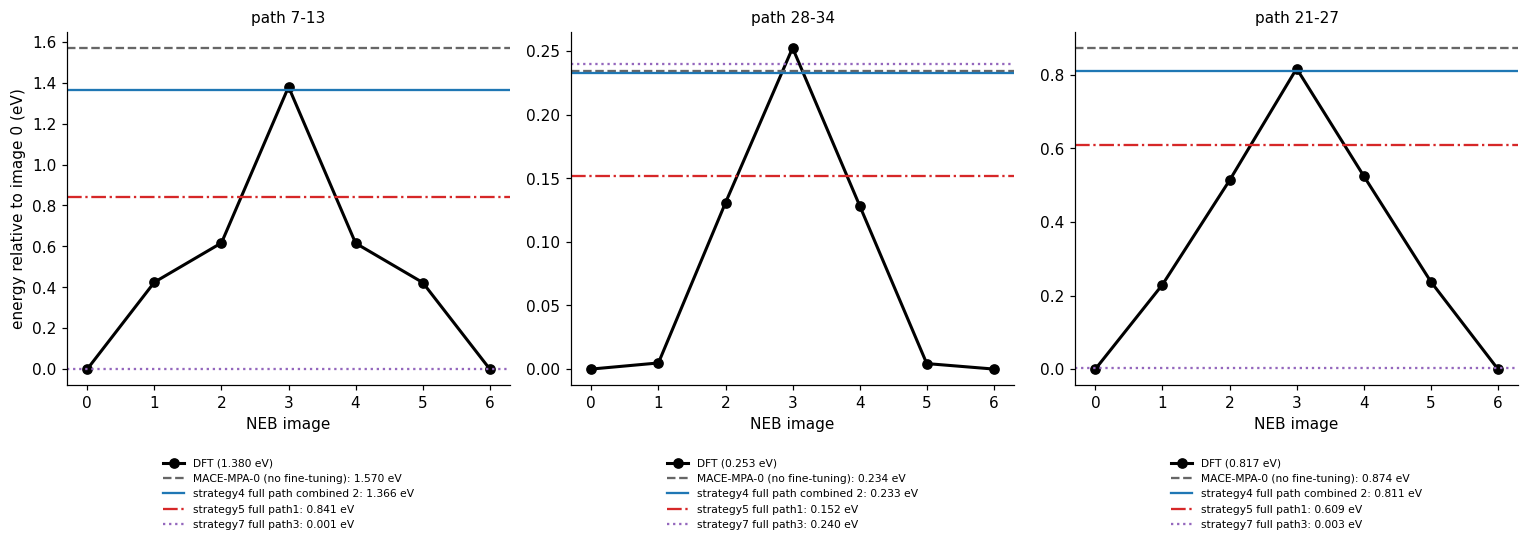

In [7]:
pick = {"MACE-MPA-0 (no fine-tuning)": ("0.4", "--"), "strategy4_full_path_combined_2": ("#1f77b4", "-"),
        "strategy5_full_path1": ("#d62728", "-."), "strategy7_full_path3": ("#9467bd", ":")}
fig, axes = plt.subplots(1, 3, figsize=(14, 5.2))
for ax, (path, rng_) in zip(axes, [("7-13", range(7, 14)), ("28-34", range(28, 35)), ("21-27", range(21, 28))]):
    e = E[list(rng_)] - E[rng_[0]]
    ax.plot(range(7), e, "ko-", lw=2, label=f"DFT ({dft_barrier[path]:.3f} eV)")
    for m, (c, ls) in pick.items():
        v = table.loc[m, path]
        if not np.isnan(v):
            ax.axhline(v, color=c, ls=ls, lw=1.5, label=f"{m.replace('_', ' ')}: {v:.3f} eV")
    ax.set_title(f"path {path}"); ax.set_xlabel("NEB image")
    ax.legend(frameon=False, fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.18))
axes[0].set_ylabel("energy relative to image 0 (eV)")
fig.tight_layout(); save(fig, "na2o/dft_profiles_vs_model_barriers")

Original climbing-image NEB bands of the same models (saved by the NEB runs; ASE `NEBTools` plots).

'figures/na2o/neb_bands_selected_models.png'

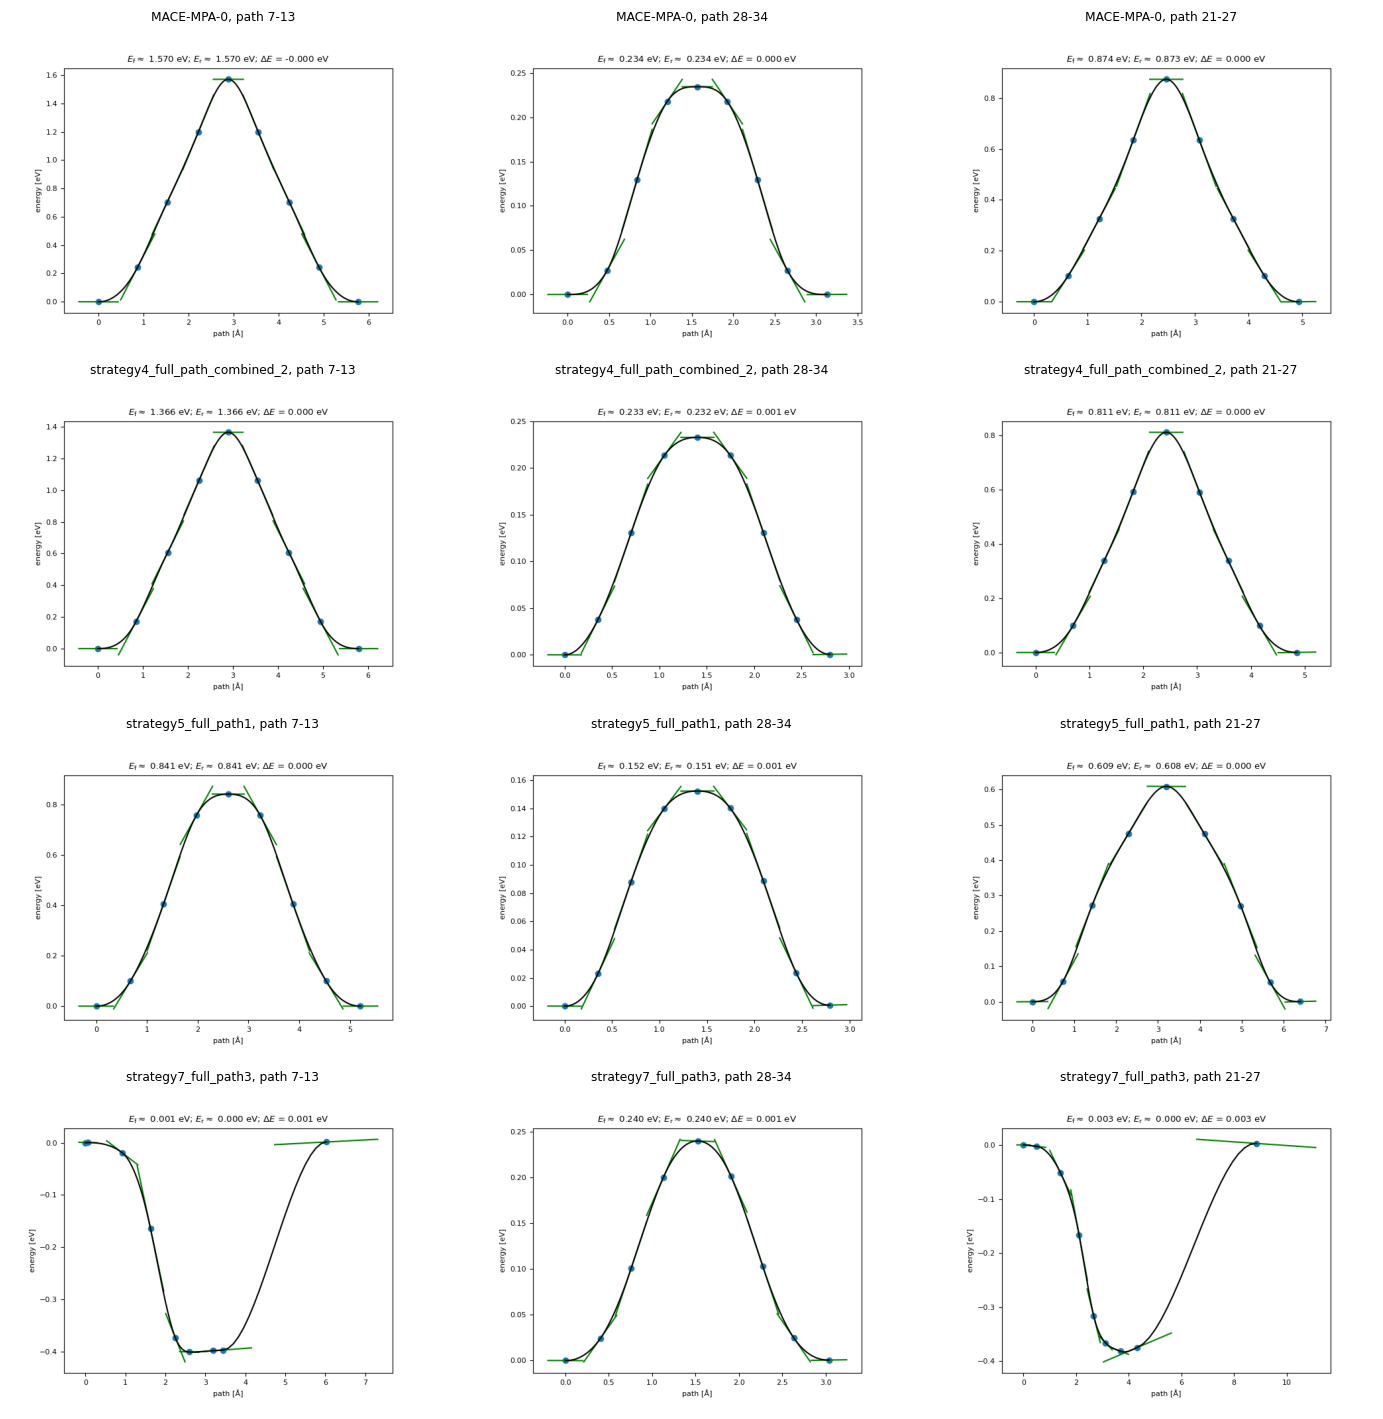

In [8]:
import matplotlib.image as mpimg
models = ["universal_mace", "strategy4_full_path_combined_2", "strategy5_full_path1", "strategy7_full_path3"]
fig, axes = plt.subplots(4, 3, figsize=(13, 13))
for i, m in enumerate(models):
    for j, path in enumerate(["7_13", "28_34", "21_27"]):
        axes[i, j].imshow(mpimg.imread(f"../results/na2o/neb_band_plots/neb_plot_{path}_{m}.png")); axes[i, j].axis("off")
        axes[i, j].set_title(f"{'MACE-MPA-0' if m == 'universal_mace' else m}, path {path.replace('_', '-')}", fontsize=8)
fig.tight_layout(); save(fig, "na2o/neb_bands_selected_models")

## Training errors of the strategy models

Each strategy is trained on 1–18 frames, and its validation/test sets contain 1–6 frames, so these
errors describe fit quality on the selected images only; the NEB barriers above are the meaningful test.

In [9]:
rows = []
for r in sorted(runs, key=lambda r: int(r["label"].split("_")[0].replace("strategy", ""))):
    last = [d for d in r["val_per_epoch"] if d["epoch"] is not None][-1]
    test = r["final_error_tables"]["test"][0]
    rows.append({"strategy": r["label"], "epochs": len(r["train_loss_epoch_mean"]),
                 "valid F MAE, last epoch (meV/Å)": round(1000 * last["mae_f"], 2),
                 "valid E MAE, last epoch (meV/atom)": round(1000 * last["mae_e_per_atom"], 2),
                 "test E MAE (meV/atom)": test["MAE E / meV / atom"], "test F MAE (meV/Å)": test["MAE F / meV / A"]})
pd.DataFrame(rows).set_index("strategy")

,epochs,"valid F MAE, last epoch (meV/Å)","valid E MAE, last epoch (meV/atom)",test E MAE (meV/atom),test F MAE (meV/Å)
strategy,,,,,
strategy1_full_path_combined,400,9.08,2.84,2.3,1.2
strategy2_half_path_combined,400,1.30,3.06,2.2,0.5
strategy3_endpoints_transition_combined,400,16.11,9.99,7.6,28.2
strategy4_full_path_combined_2,400,0.27,1.12,0.8,0.8
strategy5_full_path1,400,0.66,2.11,5.9,2.1
strategy6_full_path2,400,0.39,2.35,39.2,3.5
strategy7_full_path3,400,0.07,0.19,1.3,0.4
strategy8_half_path1,400,0.64,1.71,5.7,2.0
strategy9_half_path2,400,0.41,1.86,4.9,0.9


## Findings

* **The foundation model overestimates the two larger barriers.** MACE-MPA-0 gives 1.570 eV on path
  7–13 (DFT 1.380) and 0.874 eV on 21–27 (DFT 0.817), and is close on 28–34 (0.234 vs 0.253).
* **Fine-tuning on every image of all three hops works best.** Strategy 4 (all 15 transition-region
  images of the three paths plus endpoints) gives 1.366 / 0.233 / 0.811 eV, a mean absolute error of
  0.013 eV, against 0.088 eV for the foundation model. Strategies 1 and 2 (fewer images, also from all
  three paths) fix the 7–13 barrier but underestimate 21–27 (0.602 and 0.711 eV); strategy 1's mean
  error (0.115 eV) is larger than the foundation model's.
* **Fine-tuning on a single path distorts the other paths.** For example, training on path3 only
  (strategy 7) gives 0.001 eV on 7–13 and 0.003 eV on 21–27: the barrier collapses.
* **Even the equivalent hop is not reproduced from one path's images alone.** Strategy 5 trains on every
  image of path1, yet predicts 0.609 eV for the symmetry-equivalent path 21–27 (DFT 0.817 eV), worse than
  the foundation model. With only 6 training frames the model fits those images but the NEB, which starts
  from model-relaxed endpoints and relaxes a new band, explores configurations outside them.

Caveats: one random seed per strategy; NEB convergence beyond the reported barrier was not re-checked;
models were trained on energies and forces only.